<a href="https://colab.research.google.com/github/AKookani/BrickwallCliffordCircuit/blob/main/Toy_MIPTs_with_Qiskit_Stablizers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stabilizer Formalism & Clifford Circuits

In [1]:
!pip install qiskit ipywidgets
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 106.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=86c89fc7778542ca35f855bca02d3c4de067c9ac2cc81a4e9c957d62caaa024d
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


## Explanation of Qiskit stablizer

`qiskit.quantum_info.StabilizerState` represents a **stabilizer quantum state** in Qiskit.

A stabilizer state is any quantum state that can be fully described by **Pauli stabilizers** instead of a full statevector. This makes operations on Clifford circuits very efficient.

Typical examples:

* $|0\rangle$
* $|+\rangle$
* Bell states

### Example 1: Create $|0\rangle$ stabilizer

In [2]:
from qiskit.quantum_info import StabilizerState, Statevector, SparsePauliOp

stabilizer_state = StabilizerState.from_stabilizer_list(["Z"]) #returns the state is stabilized by Z operator
print(stabilizer_state)

StabilizerState(['+Z'])


Here, `"Z"` means the state is stabilized by the Pauli (Z) operator:

$Z|0\rangle = |0\rangle$

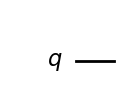

In [3]:
Clifford_circuit = stabilizer_state.clifford.to_circuit()
display(Clifford_circuit.draw('mpl'))

.clifford means What Clifford tableau internally represents this stabilizer state?

In [4]:
psi = Statevector.from_instruction(Clifford_circuit)
display(psi.draw('latex'))

<IPython.core.display.Latex object>

- **`Clifford`** — represents a Clifford *operation* (unitary). Internally it stores a tableau (symplectic matrix + phases) describing how that operation conjugates each Pauli generator. There's no "Clifford state" — `Clifford` is always an operator, never a state.
- **`StabilizerState`** — represents a stabilizer *state*. Internally it stores a `Clifford` object as its underlying data structure, but interprets it as: "the state obtained by applying this Clifford to $|0\rangle^{\otimes n}$." So a `StabilizerState`'s tableau is literally "what Pauli generators does $|0\rangle^{\otimes n}$ get mapped to" — i.e. the stabilizer generators of the resulting state.

In [5]:
psi = Statevector.from_label('0')
print(psi.expectation_value(SparsePauliOp('Z')))

(1+0j)


In [6]:
psi = Statevector.from_label('1')
print(psi.expectation_value(SparsePauliOp('Z')))

(-1+0j)


In [7]:
psi = Statevector.from_label('+')
print(psi.expectation_value(SparsePauliOp('Z')))

0j


### Example 2: Bell state

The Bell state

[
$\frac{|00\rangle + |11\rangle}{\sqrt2}$
]

is stabilized by

* (XX)
* (ZZ)

In [8]:
from qiskit.quantum_info import StabilizerState

bell = StabilizerState.from_stabilizer_list([
    "XX",
    "ZZ"
])

print(bell)

StabilizerState(['+XX', '+ZZ'])


### Example 3: From a Clifford circuit

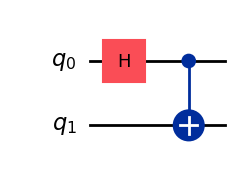

StabilizerState(['+XX', '+ZZ'])


In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import StabilizerState

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
display(qc.draw('mpl'))

state = StabilizerState(qc)
print(state)

## Stabilizer State Efficiency

**When to use Stabilizer State**

Use `StabilizerState` when your circuit only contains **Clifford gates**, such as:

* H
* S
* X, Y, Z
* CNOT (CX)
* SWAP

It is **much more memory-efficient** than a full statevector for these circuits.

If your circuit contains non-Clifford gates like `T`, `CCX` (Toffoli, in general), or arbitrary rotations (`RX`, `RY`, `RZ` with arbitrary angles), then `StabilizerState` is generally not applicable, and you'd instead use something like `Statevector`.

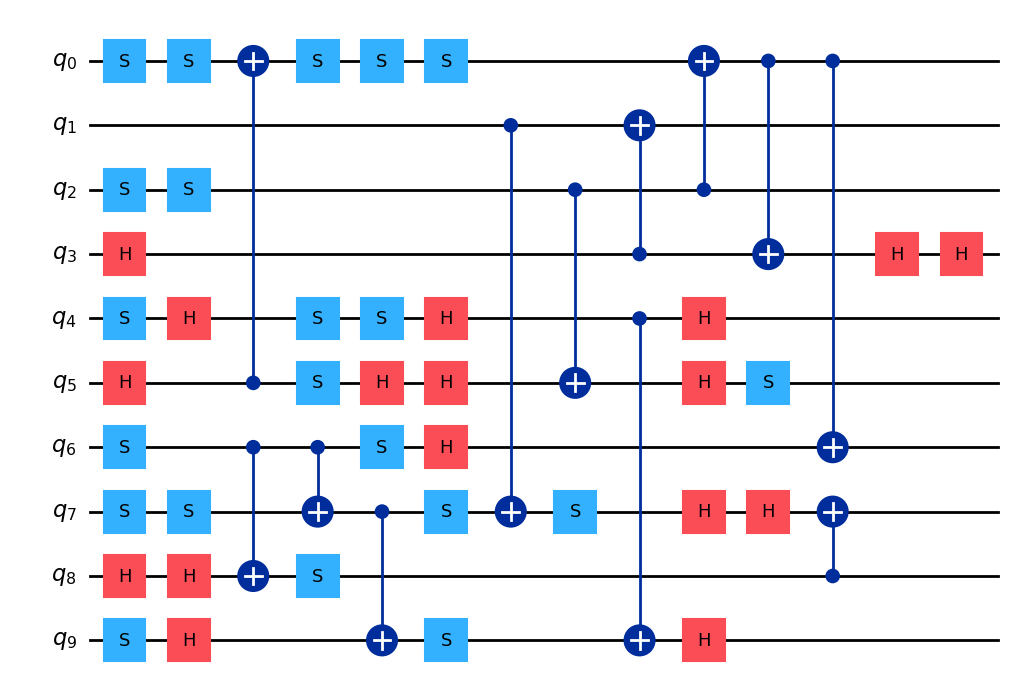

In [9]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import StabilizerState
import random

n = 10
qc = QuantumCircuit(n)

for _ in range(50):
    gate = random.choice(["h", "s", "cx"])

    if gate == "h":
        qc.h(random.randrange(n))

    elif gate == "s":
        qc.s(random.randrange(n))

    else:
        a, b = random.sample(range(n), 2)
        qc.cx(a, b)

qc.draw("mpl")

In [10]:
stab = StabilizerState(qc)

print(stab) #There will be 10 generators because we have 10 qubits.

StabilizerState(['+IIIIYIIIIZ', '+IIIIIIZIZZ', '+IIIIIIIZII', '+IIIIIIXIXI', '-IIIIIXIIII', '-IIIXXIXIIY', '+IIIXIIIIII', '+IZZXIIZIZZ', '+IZIXIIIIII', '-YIIIIXIIII'])


In [11]:
from qiskit.quantum_info import Statevector

psi = Statevector.from_instruction(qc)

psi.draw('latex')

<IPython.core.display.Latex object>

# Measurement-induced dynamics in **Clifford circuits** using the **stabilizer formalism**

**Projective measurements** simulation on **random Clifford ciruits** to measure **entanglement entropy** and **purification time**.

##1 — A stabilizer state

In [12]:
from qiskit.quantum_info import StabilizerState

# |000>
state = StabilizerState.from_stabilizer_list([
    "+ZII",
    "+IZI",
    "+IIZ"
])

print(state)

StabilizerState(['+ZII', '+IZI', '+IIZ'])


###Clifford circuits and Stabilizer Tableaus

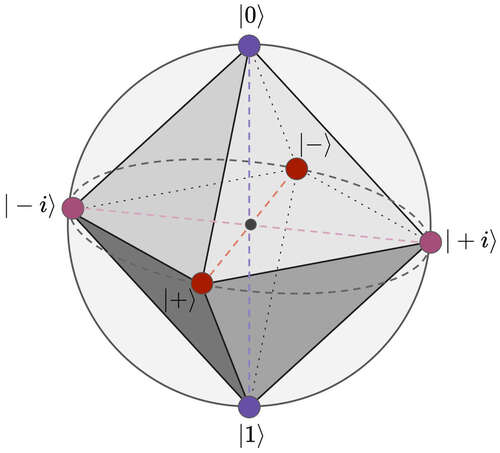

**The octahedron in the Bloch sphere defines the states accessible via single-qubit Clifford gates.**

$|000\rangle$ has generators $\{Z_1, Z_2, Z_3\}$.

$ZZZ$ (i.e. $Z_1Z_2Z_3$) stabilizes $|000\rangle$. So it's a valid member of the **stabilizer group**. But it's not a **generator** of $|000\rangle$, because it's just the product $Z_1 \cdot Z_2 \cdot Z_3$ of the actual generators; it's redundant, not independent.

So $ZZZ$ is *a* stabilizer of $|000\rangle$, but it is *not* one of its generators.

Three simple conditions for a set to count as generators of an n-qubit state:

1. **They're real stabilizers.** Each one has to actually stabilize the state (give +1 when applied).

2. **None is redundant.** You can't build any one of them by multiplying the others together. Each one adds something new.

3. **There are exactly n of them.** For n qubits, you need exactly n generators — no more, no less.

That's it. Also worth knowing: the generator set isn't unique. For $|00\rangle$, $\{Z_1, Z_2\}$ works, but so does $\{Z_1, Z_1Z_2\}$ — different lists, same state, both valid.

In [13]:
Clifford_tabeleau = state.clifford
Clifford_tabeleau.tableau.astype(int)

array([[0, 0, 1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0, 0, 0]])

**Top — the table layout:**

| | columns 1..n | columns n+1..2n | last column |
|---|---|---|---|
| rows 1..n | $x$ part | $z$ part | $r$ (phase) |
| **(this block = Destabilizers)** | | | |
| rows n+1..2n | $x$ part | $z$ part | $r$ (phase) |
| **(this block = Stabilizers)** | | | |

$2n \times (2n+1)$ matrix. Top half = destabilizer rows, bottom half = stabilizer rows. Each row has $n$ bits for $X$-content, $n$ bits for $Z$-content, and 1 bit for sign.

For $|000\rangle$, `state.clifford` prints:
```
Stabilizer    = ['+ZII', '+IZI', '+IIZ']
Destabilizer  = ['+XII', '+IXI', '+IIX']
```

In the diagram's matrix form (3 qubits, so $n=3$, 6 rows total):

```
              x1 x2 x3   z1 z2 z3   r
destab row1:   0  0  1    0  0  0   0     →  +XII
destab row2:   0  1  0    0  0  0   0     →  +IXI
destab row3:   1  0  0    0  0  0   0     →  +IIX
---------------------------------------------
stab row1:     0  0  0    0  0  1   0     →  +ZII
stab row2:     0  0  0    0  1  0   0     →  +IZI
stab row3:     0  0  0    1  0  0   0     →  +IIZ
```

**To turn the clifford tableau into a state vector, we need a circuit intermediary**

In [14]:
from qiskit.quantum_info import Statevector

sv = Statevector.from_instruction(Clifford_tabeleau.to_circuit())

sv.draw('latex')

<IPython.core.display.Latex object>

##2 — Random Clifford circuit

In [18]:
import numpy as np
from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import Clifford

rng = np.random.default_rng()

qc = QuantumCircuit(3)

for _ in range(5):

    gate = rng.choice(["H","S","CX"])

    if gate=="H":
        qc.h(rng.integers(3))

    elif gate=="S":
        qc.s(rng.integers(3))

    else:
        q1,q2 = rng.choice(3,2,replace=False)
        qc.cx(q1,q2)

cliff = Clifford(qc)

state = state.evolve(cliff)

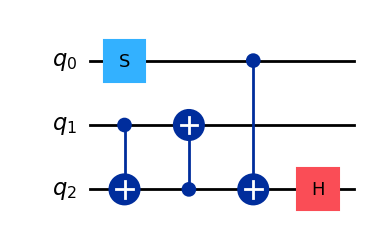

array([[1, 0, 0, 1, 0, 1, 0],
       [0, 0, 0, 0, 0, 1, 0],
       [0, 1, 0, 0, 0, 1, 0],
       [0, 0, 0, 1, 0, 0, 0],
       [0, 0, 1, 1, 1, 0, 0],
       [0, 0, 0, 0, 1, 0, 0]])

In [19]:
display(qc.draw('mpl'))
cliff.tableau.astype(int)

In [20]:
Statevector.from_instruction(state.clifford.to_circuit()).draw('latex')

<IPython.core.display.Latex object>

In [21]:
state

StabilizerState(['+ZYI', '+XZZ', '+IIZ'])

##3 — Pauli operators

In [22]:
from qiskit.quantum_info import Pauli

P = Pauli("XZI") # Creates the Pauli operator P

print(P)

XZI


In [23]:
P1 = Pauli("XII")
P2 = Pauli("ZII")

print(P1.anticommutes(P2))

True


Check whether two Pauli operators **anticommute**.

* On the **same qubit**, Pauli operators **X and Z anticommute**:
  $$
  XZ = -ZX
  $$

* Since both operators act non-trivially on **qubit 0**, and X and Z anticommute there, the overall operators also anticommute.

The code returns `True` because `XII` and `ZII` anticommute (due to X and Z on the same qubit).


### 🔹 “Non-trivially” means:

An operator acts **non-trivially** on a qubit if it actually **does something to that qubit** (i.e., it’s not the identity).

* **Non-trivial action:** `X`, `Y`, or `Z`
  * These change the qubit state (flip, phase, etc.)
* **Trivial action:** `I` (identity)
  * Does **nothing** to the qubit

***
### 🧠 Why it matters:

Commutation/anticommutation depends only on qubits where **both operators act non-trivially**.

* If both act with real Pauli matrices (X, Y, Z) on the same qubit → check their relation
* If one or both are `I` → they don’t affect commutation


In [24]:
P1.compose(P2)

Pauli('iYII')

`P1.compose(P2)` computes the **product (composition)** of the two Pauli operators.

* It applies **P2 first**, then **P1** (i.e., matrix multiplication order).
* On qubit 0:  
  $$X \cdot Z = iY$$ (up to a phase factor)

### Result:

* The resulting Pauli operator is essentially **`YII`**, plus a **global phase factor** (like $$i$$ or $$-i$$) that Qiskit keeps track of internally.


##4 — Measuring a Pauli

In [28]:
from qiskit.quantum_info import Pauli

observable = Pauli("ZII")

# Is the measurement deterministic?
print(state)
print(state.expectation_value(observable))

StabilizerState(['+ZYI', '+XZZ', '+IIZ'])
0


The **stabilizer state** is defined by 3 generators:
  * `+ZYI`
  * `+XZZ`
  * `+IIZ`
* These operators define a quantum state.

***

```python
observable = Pauli("ZII")
```

* Defines a measurement operator:
  * **Z on qubit 0**, identity on qubits 1 and 2

***

```python
print(state.expectation_value(observable))
```

* Computes the **expectation value** of measuring `ZII` on that state

***

### 🔹 Interpretation

* If the result is **+1 or −1** → the measurement is definite (**deterministic**)
* If it’s something else (e.g., 0) → the outcome is **random**

##5 — Entanglement entropy

In [30]:
from qiskit.quantum_info import partial_trace
from qiskit.quantum_info import entropy

rho = state.to_operator()
rho.draw('latex')
# (For general states we'd convert to a density matrix first.)

<IPython.core.display.Latex object>

##6 — Simulation loop

In [36]:
import numpy as np

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# -----------------------------
# Parameters
# -----------------------------

n = 4          # number of qubits
T = 5          # circuit depth
p = 0.3        # measurement probability

rng = np.random.default_rng()

# -----------------------------
# Initial state |0000>
# -----------------------------

qc = QuantumCircuit(n)

# -----------------------------
# Random Clifford evolution
# -----------------------------

for t in range(T):

    # Single-qubit Clifford layer
    for q in range(n):

        gate = rng.choice(["H", "S", "I"])

        if gate == "H":
            qc.h(q)

        elif gate == "S":
            qc.s(q)

    # Two-qubit entangling layer
    for q in range(n - 1):

        if rng.random() < 0.5:
            qc.cx(q, q + 1)

# -----------------------------
# Final state before measurements
# -----------------------------

psi = Statevector.from_instruction(qc)

print("Statevector dimension:")
print(len(psi))

# -----------------------------
# Random measurements
# -----------------------------

for q in range(n):

    if rng.random() < p:

        outcome, collapsed = psi.measure([q])

        psi = collapsed

        print(f"Measured qubit {q} -> outcome {outcome}")

# -----------------------------
# Final state
# -----------------------------

print("\nFinal state:")
psi.draw('latex')

Statevector dimension:
16
Measured qubit 2 -> outcome 0

Final state:


<IPython.core.display.Latex object>

In [37]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

n = 4
T = 10
p = 0.3

rng = np.random.default_rng()

psi = Statevector.from_label("0" * n)

for t in range(T):

    qc = QuantumCircuit(n)

    # random Clifford layer
    for q in range(n):

        gate = rng.choice(["H", "S", "I"])

        if gate == "H":
            qc.h(q)

        elif gate == "S":
            qc.s(q)

    # nearest-neighbor CNOTs
    for q in range(n - 1):

        if rng.random() < 0.5:
            qc.cx(q, q + 1)

    psi = psi.evolve(qc)

    # measurements
    for q in range(n):

        if rng.random() < p:

            outcome, collapsed = psi.measure([q])

            psi = collapsed

            print(
                f"time={t:2d}, qubit={q}, outcome={outcome}"
            )

print("\nFinished.")
print("State dimension =", len(psi))

time= 0, qubit=1, outcome=0
time= 1, qubit=3, outcome=0
time= 2, qubit=1, outcome=1
time= 4, qubit=3, outcome=1
time= 5, qubit=0, outcome=0
time= 5, qubit=2, outcome=1
time= 6, qubit=1, outcome=0
time= 7, qubit=0, outcome=0
time= 7, qubit=2, outcome=1
time= 7, qubit=3, outcome=0
time= 8, qubit=1, outcome=0

Finished.
State dimension = 16
